# Fraud in Wine
## use support vector machines to build a model capable of recognising fraud wine from a chemical analysis

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../../jupyter_notebooks/DATA/wine_fraud.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


In [7]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

<Axes: xlabel='quality', ylabel='count'>

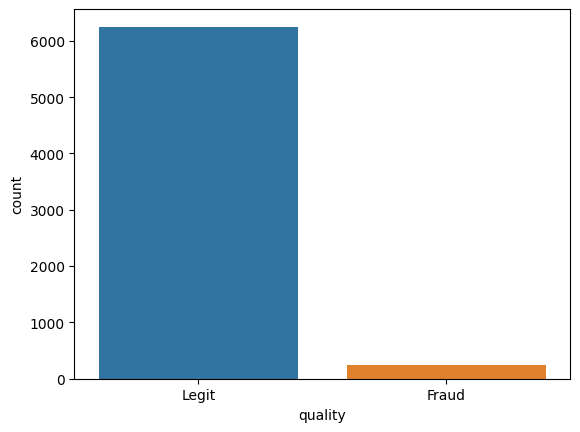

In [8]:
sns.countplot(data=df,x='quality', hue='quality')

<Axes: xlabel='type', ylabel='count'>

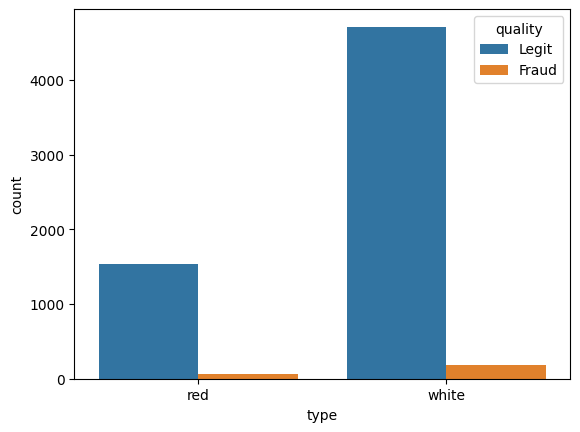

In [9]:
sns.countplot(data=df, x='type', hue='quality')

### Percentage of fraud of red and white wines

In [10]:
df[(df['type']=='red')&(df['quality']=='Fraud')]['quality'].count()/df[(df['type']=='red')]['quality'].count() * 100

np.float64(3.9399624765478425)

In [11]:
df[(df['type']=='white')&(df['quality']=='Fraud')]['quality'].count()/df[(df['type']=='white')]['quality'].count() * 100

np.float64(3.7362188648427925)

In [12]:
df['ntype']=df['type'].map({'red':2,'white':1})

In [13]:
#Check that 2 is accurately representing red
df[(df['ntype']==2)&(df['quality']=='Fraud')]['quality'].count()/df[(df['ntype']==2)]['quality'].count() * 100

np.float64(3.9399624765478425)

In [14]:
#Check that 1 is accurately representing white
df[(df['ntype']==1)&(df['quality']=='Fraud')]['quality'].count()/df[(df['ntype']==1)]['quality'].count() * 100

np.float64(3.7362188648427925)

In [15]:
df['Fraud']=df['quality'].map({'Fraud':1,'Legit':0})

In [16]:
correlations=df.drop(['type','quality'],axis=1).corr()
correlations['Fraud']

fixed acidity           0.021794
volatile acidity        0.151228
citric acid            -0.061789
residual sugar         -0.048756
chlorides               0.034499
free sulfur dioxide    -0.085204
total sulfur dioxide   -0.035252
density                 0.016351
pH                      0.020107
sulphates              -0.034046
alcohol                -0.051141
ntype                   0.004598
Fraud                   1.000000
Name: Fraud, dtype: float64

<Axes: ylabel='Fraud'>

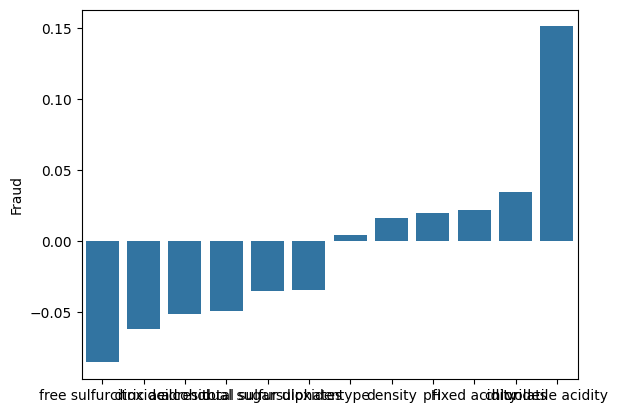

In [17]:
sns.barplot(correlations['Fraud'].drop('Fraud',axis=0).sort_values())

## You can also produce the same figure easier with pandas shortcut .plot

<Axes: >

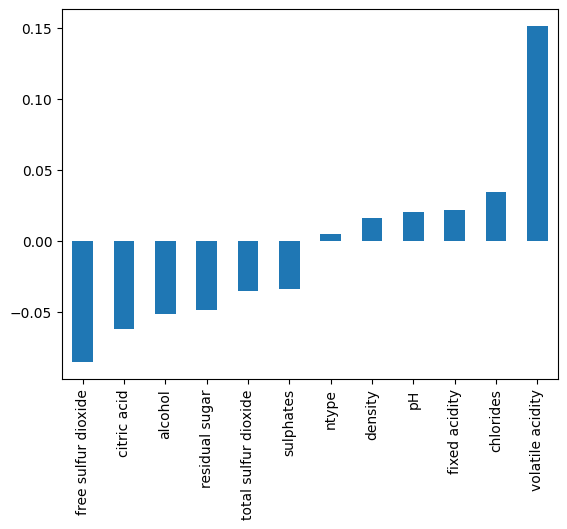

In [28]:
correlations['Fraud'].drop('Fraud',axis=0).sort_values().plot(kind='bar')

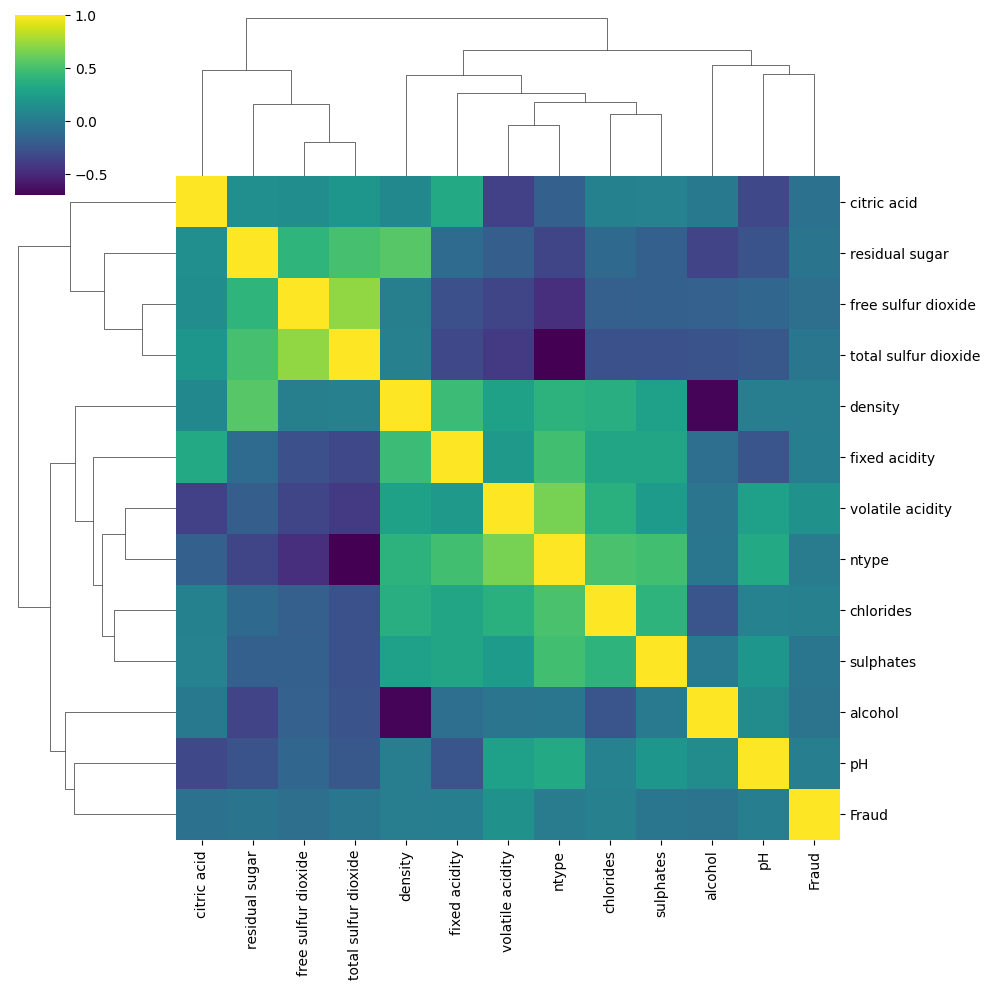

In [16]:
sns.clustermap(data=correlations,annot=False,cmap='viridis')

In [18]:
df=df.drop('ntype',axis=1)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,Fraud
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,Legit,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,Legit,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,Legit,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,red,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,Legit,white,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,Legit,white,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,Legit,white,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,Legit,white,0


In [19]:
df=df.drop('quality',axis=1)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,Fraud
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,red,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,white,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,white,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,white,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,white,0


In [20]:
df['type']=pd.get_dummies(df['type'],drop_first=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,Fraud
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,False,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,False,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,False,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,False,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,True,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,True,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,True,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,True,0


In [21]:
X=df.drop('Fraud',axis=1)
y=df['Fraud']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler=StandardScaler()

In [26]:
scaled_X_train=scaler.fit_transform(X_train)
scaled_x_test=scaler.transform(X_test)

In [27]:
from sklearn.svm import SVC

In [30]:
svc_model=SVC(class_weight='balanced')

In [31]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid={'C':[0.001,0.01,0.1,0.5,1,1.5,2],'gamma':['scale','auto']}

In [39]:
grid=GridSearchCV(svc_model,param_grid)

In [40]:
grid.fit(scaled_X_train,y_train)

,estimator,SVC(class_weight='balanced')
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,2


In [41]:
grid.best_params_

{'C': 2, 'gamma': 'scale'}

In [48]:
from sklearn.metrics import confusion_matrix,classification_report

In [46]:
grid_pred = grid.predict(scaled_x_test)

In [47]:
confusion_matrix(y_test,grid_pred)

array([[537,  86],
       [ 10,  17]])

In [49]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       623
           1       0.17      0.63      0.26        27

    accuracy                           0.85       650
   macro avg       0.57      0.75      0.59       650
weighted avg       0.95      0.85      0.89       650



## Conclussion

This model performed poorly on detecting the fraud wines. It spotted the legit wines quite accurately, but by not spotting almost half of the fraud ones; taking into account that the fraud ones are the true target of the model, this model performed pooly at spotting them. It is not advisable to use it in production.